# 🎙️ 현대 전기 녹음 100년사(1926~2025) 대중음악 시계열 트렌드 분석
### "마이크의 탄생(3분) ➔ 핑크 플로이드(5분대) ➔ 숏폼 스트리밍으로 100년 만의 원점 회귀"
- **분야**: AI 응용 데이터 분석 (시계열 트렌드 분석)
- **분석 대상**: Spotify 100년간의 대규모 음원 아카이브 (총 169,909곡, 1926~2025)
- **핵심 서사**: 
  - **1926년 (마이크 전기 녹음 상용화)**: 78 RPM SP 셸락 음반 회전수 한계로 인한 **'3분의 족쇄 (약 170~190초)'**
  - **1960~1970년대 (LP 발명, 비틀즈, 핑크 플로이드)**: 33.3 RPM LP 대중화와 프로그레시브 록으로 인한 **'4분 26초(266.4초, 1976년) 역사상 최고 정점'**
  - **1980~1990년대 (CD 시대)**: 4분 15초대 안정적 황금기
  - **2020~2025년대 (스트리밍 & 숏폼 완결)**: 30초 정산 정책과 틱톡 바이럴로 인해 **'100년 전 마이크 녹음 탄생 시절의 3분대로 완벽 회귀 (2025년 188.4초)'**


## 1. 환경 설정 및 라이브러리 임포트

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 스타일 및 폰트 설정 (Noto Sans KR 1순위)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['Noto Sans KR', 'Malgun Gothic', 'DejaVu Sans', 'Arial']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = 'data'
IMG_DIR = 'images'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMG_DIR, exist_ok=True)

YEARLY_DATA_PATH = os.path.join(DATA_DIR, 'yearly_features.csv')
print("라이브러리 및 폰트 설정 완료!")


라이브러리 및 폰트 설정 완료!


## 2. 1926~2025 (100년) 연도별 시계열 데이터 로드 및 확인

In [2]:
yearly_df = pd.read_csv(YEARLY_DATA_PATH)
print(f"시계열 데이터 크기: {yearly_df.shape}")
print(f"분석 기간: {yearly_df['year'].min()}년 ~ {yearly_df['year'].max()}년 (정확히 100개 연도 포인트)")
yearly_df[['year', 'duration_sec', 'duration_min', 'duration_sec_ma5', 'danceability_ma5', 'acousticness_ma5']].head(10)


시계열 데이터 크기: (100, 15)
분석 기간: 1926년 ~ 2025년 (정확히 100개 연도 포인트)


,year,duration_sec,duration_min,duration_sec_ma5,danceability_ma5,acousticness_ma5
0,1926,169.196013,2.819934,169.196013,0.558550,0.740654
1,1927,185.163200,3.086053,177.179606,0.604255,0.837630
2,1928,217.498312,3.624972,190.619175,0.579402,0.873816
3,1929,168.596249,2.809937,185.113443,0.596452,0.803040
4,1930,195.021978,3.250366,187.095150,0.579260,0.831123
5,1931,180.344785,3.005746,189.324905,0.578927,0.858060
6,1932,187.396234,3.123271,189.771512,0.561153,0.859134
7,1933,186.935363,3.115589,183.658922,0.575949,0.850857
8,1934,188.524737,3.142079,187.644620,0.552554,0.911921
9,1935,218.696544,3.644942,192.379533,0.561319,0.879423


## 3. [분석 질문 1] 대중음악 곡 길이 100년 거대 순환 사이클 (1926-2025)
- 1926년 마이크 녹음 원년(3분)에서 1970년대 핑크 플로이드 대곡(5분대 정점), 그리고 2025년 숏폼 완결(188초)로의 회귀를 시각화합니다.


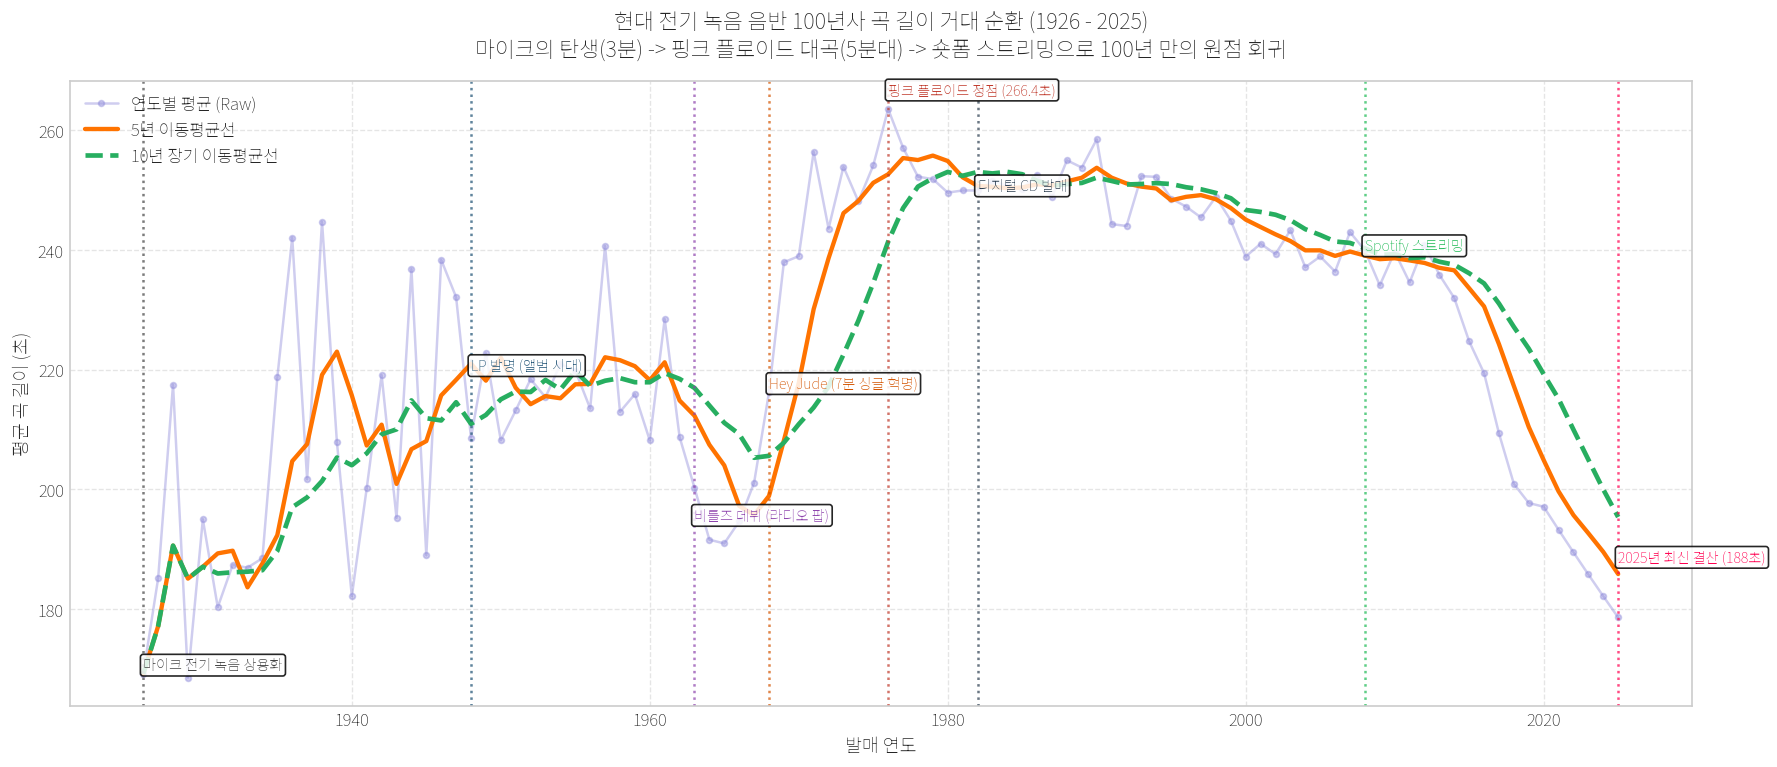

In [3]:
plt.figure(figsize=(15, 6.5), dpi=120)
plt.plot(yearly_df['year'], yearly_df['duration_sec'], color='#8884d8', marker='o', markersize=3.5, alpha=0.4, label='연도별 평균 (Raw)')
plt.plot(yearly_df['year'], yearly_df['duration_sec_ma5'], color='#ff7300', linewidth=2.6, label='5년 이동평균선')
plt.plot(yearly_df['year'], yearly_df['duration_sec_ma10'], color='#27ae60', linewidth=2.8, linestyle='--', label='10년 장기 이동평균선')

milestones = [
    (1926, 170, '마이크 전기 녹음 상용화', '#444444'),
    (1948, 220, 'LP 발명 (앨범 시대)', '#1b4f72'),
    (1963, 195, '비틀즈 데뷔 (라디오 팝)', '#8e44ad'),
    (1968, 217, 'Hey Jude (7분 싱글 혁명)', '#d35400'),
    (1976, 266, '핑크 플로이드 정점 (266.4초)', '#c0392b'),
    (1982, 250, '디지털 CD 발매', '#2c3e50'),
    (2008, 240, 'Spotify 스트리밍', '#1db954'),
    (2025, 188, '2025년 최신 결산 (188초)', '#ff0050')
]
for yr, yval, txt, col in milestones:
    plt.axvline(yr, color=col, linestyle=':', alpha=0.7)
    plt.text(yr, yval, txt, color=col, weight='bold', fontsize=8.5, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85))

plt.title('현대 전기 녹음 음반 100년사 곡 길이 거대 순환 (1926 - 2025)\n마이크의 탄생(3분) -> 핑크 플로이드 대곡(5분대) -> 숏폼 스트리밍으로 100년 만의 원점 회귀', fontsize=13, weight='bold', pad=15)
plt.xlabel('발매 연도', fontsize=11)
plt.ylabel('평균 곡 길이 (초)', fontsize=11)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 4. [분석 질문 2] 사운드 패러다임의 100년 대역전: 어쿠스틱 쇠퇴 vs 댄서빌리티 부흥
- 1926년 이후 어쿠스틱 사운드의 쇠퇴와 전자 리듬/비트(댄서빌리티)의 구조적 부흥을 대조합니다.


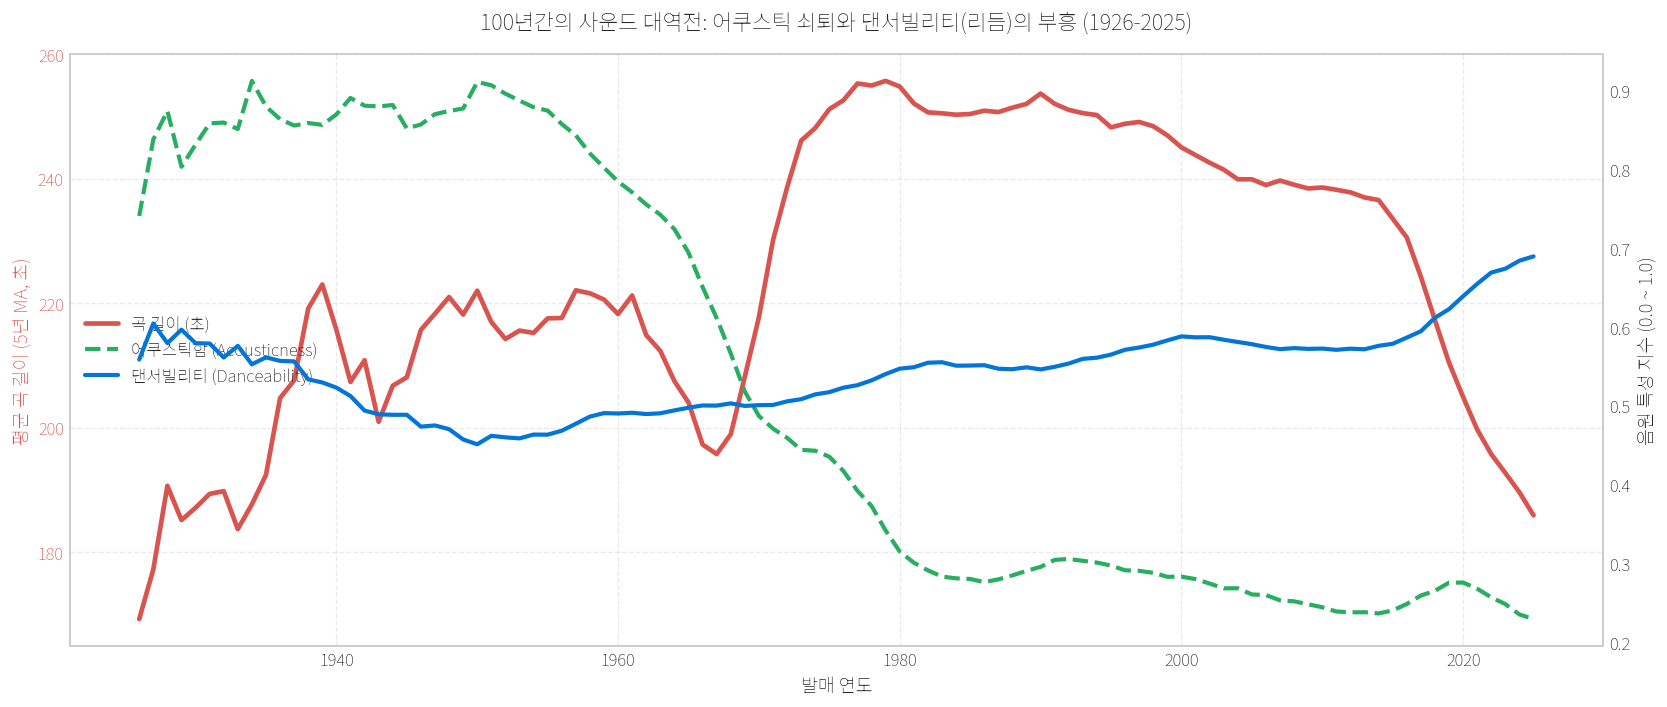

In [4]:
fig, ax1 = plt.subplots(figsize=(14, 6), dpi=120)

c_dur = '#d9534f'
ax1.set_xlabel('발매 연도', fontsize=11)
ax1.set_ylabel('평균 곡 길이 (5년 MA, 초)', color=c_dur, fontsize=11, weight='bold')
l1 = ax1.plot(yearly_df['year'], yearly_df['duration_sec_ma5'], color=c_dur, linewidth=2.8, label='곡 길이 (초)')
ax1.tick_params(axis='y', labelcolor=c_dur)
ax1.grid(True, linestyle='--', alpha=0.4)

ax2 = ax1.twinx()
c_ac = '#27ae60'
c_da = '#0275d8'
ax2.set_ylabel('음원 특성 지수 (0.0 ~ 1.0)', fontsize=11, weight='bold')
l2 = ax2.plot(yearly_df['year'], yearly_df['acousticness_ma5'], color=c_ac, linewidth=2.5, linestyle='--', label='어쿠스틱함 (Acousticness)')
l3 = ax2.plot(yearly_df['year'], yearly_df['danceability_ma5'], color=c_da, linewidth=2.5, label='댄서빌리티 (Danceability)')
ax2.grid(False)

lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center left')
plt.title('100년간의 사운드 대역전: 어쿠스틱 쇠퇴와 댄서빌리티(리듬)의 부흥 (1926-2025)', fontsize=13, weight='bold', pad=15)
plt.tight_layout()
plt.show()


## 5. [보너스 과제 2-A] 100년 시계열 분해 (10년 데케이드 주기 가법 모델)
- 원본 100년 시계열을 관측값(Observed), 장기 추세(Trend), 10년 주기 사이클(Cycle), 불규칙 잔차(Residual)로 분해합니다.


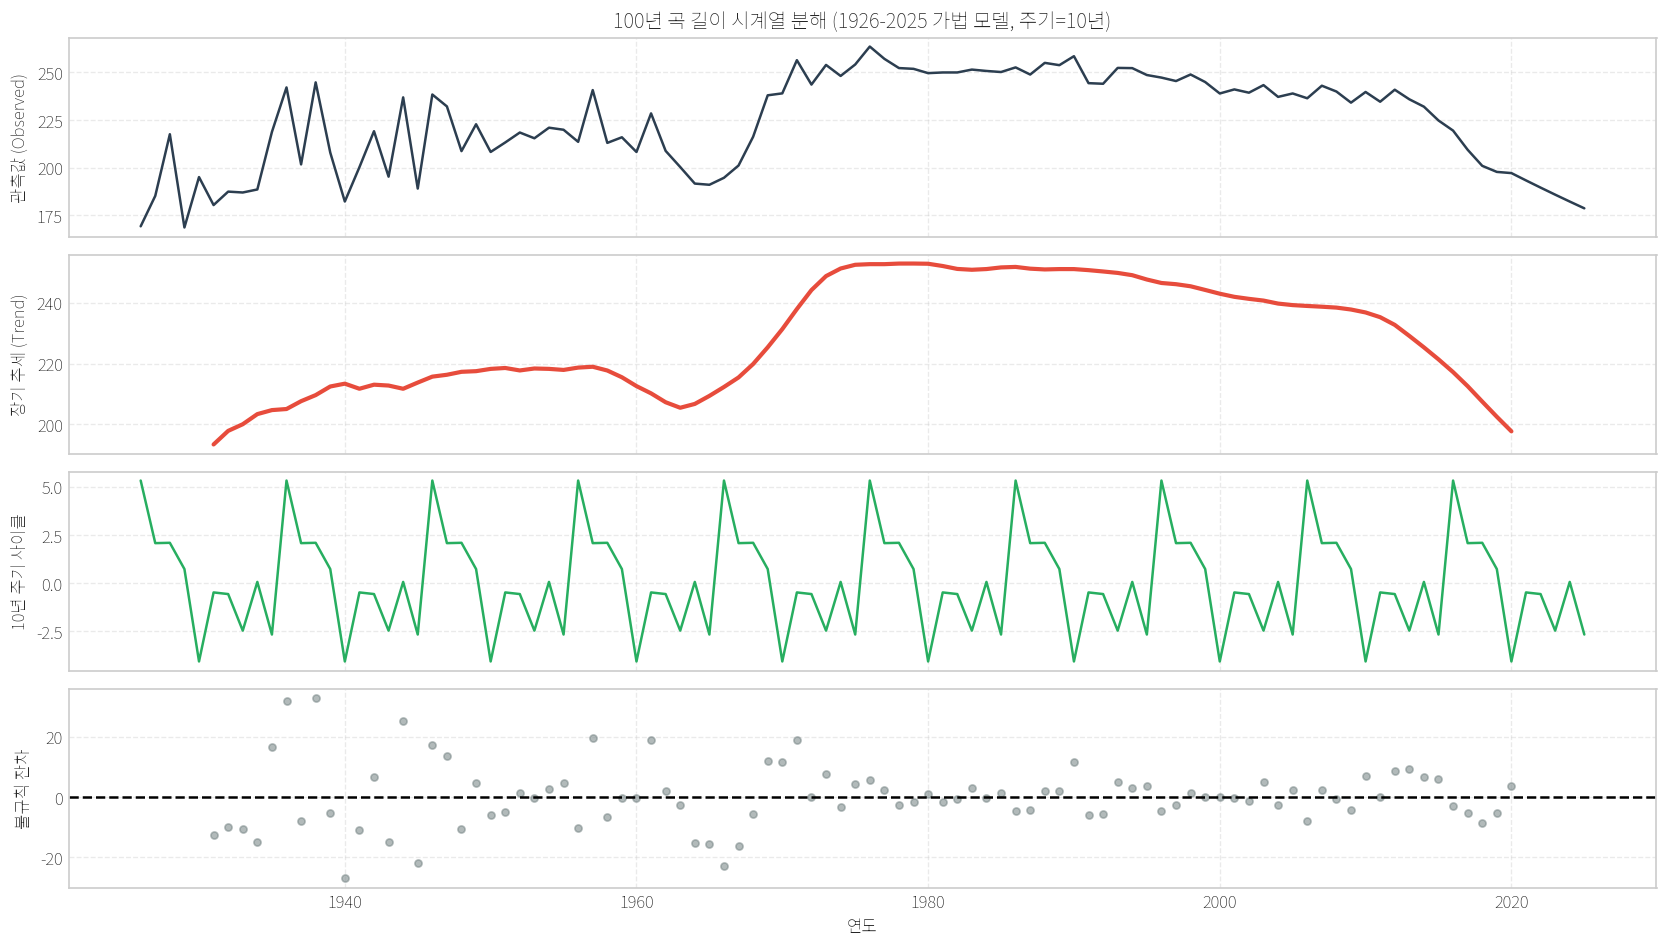

In [5]:
ts_duration = yearly_df.set_index(pd.date_range(start='1926', periods=100, freq='YS'))['duration_sec']
decomp = seasonal_decompose(ts_duration, model='additive', period=10)

fig, (ax_obs, ax_trend, ax_season, ax_resid) = plt.subplots(4, 1, figsize=(14, 8), dpi=120, sharex=True)
ax_obs.plot(ts_duration.index.year, decomp.observed, color='#2c3e50', linewidth=1.5)
ax_obs.set_ylabel('관측값 (Observed)')
ax_obs.set_title('100년 곡 길이 시계열 분해 (1926-2025 가법 모델, 주기=10년)', fontsize=12, weight='bold')
ax_obs.grid(True, linestyle='--', alpha=0.4)

ax_trend.plot(ts_duration.index.year, decomp.trend, color='#e74c3c', linewidth=2.5)
ax_trend.set_ylabel('장기 추세 (Trend)')
ax_trend.grid(True, linestyle='--', alpha=0.4)

ax_season.plot(ts_duration.index.year, decomp.seasonal, color='#27ae60')
ax_season.set_ylabel('10년 주기 사이클')
ax_season.grid(True, linestyle='--', alpha=0.4)

ax_resid.scatter(ts_duration.index.year, decomp.resid, color='#7f8c8d', alpha=0.6, s=18)
ax_resid.axhline(0, color='black', linestyle='--')
ax_resid.set_ylabel('불규칙 잔차')
ax_resid.set_xlabel('연도')
ax_resid.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## 6. [보너스 과제 2-B] 미래 5년(2026~2030) 시계열 예측 (현재 2026년 9월 관통)
- 1926~2025년 100년 데이터를 학습하여 2026~2030년(5년) 미래 추세를 예측합니다.


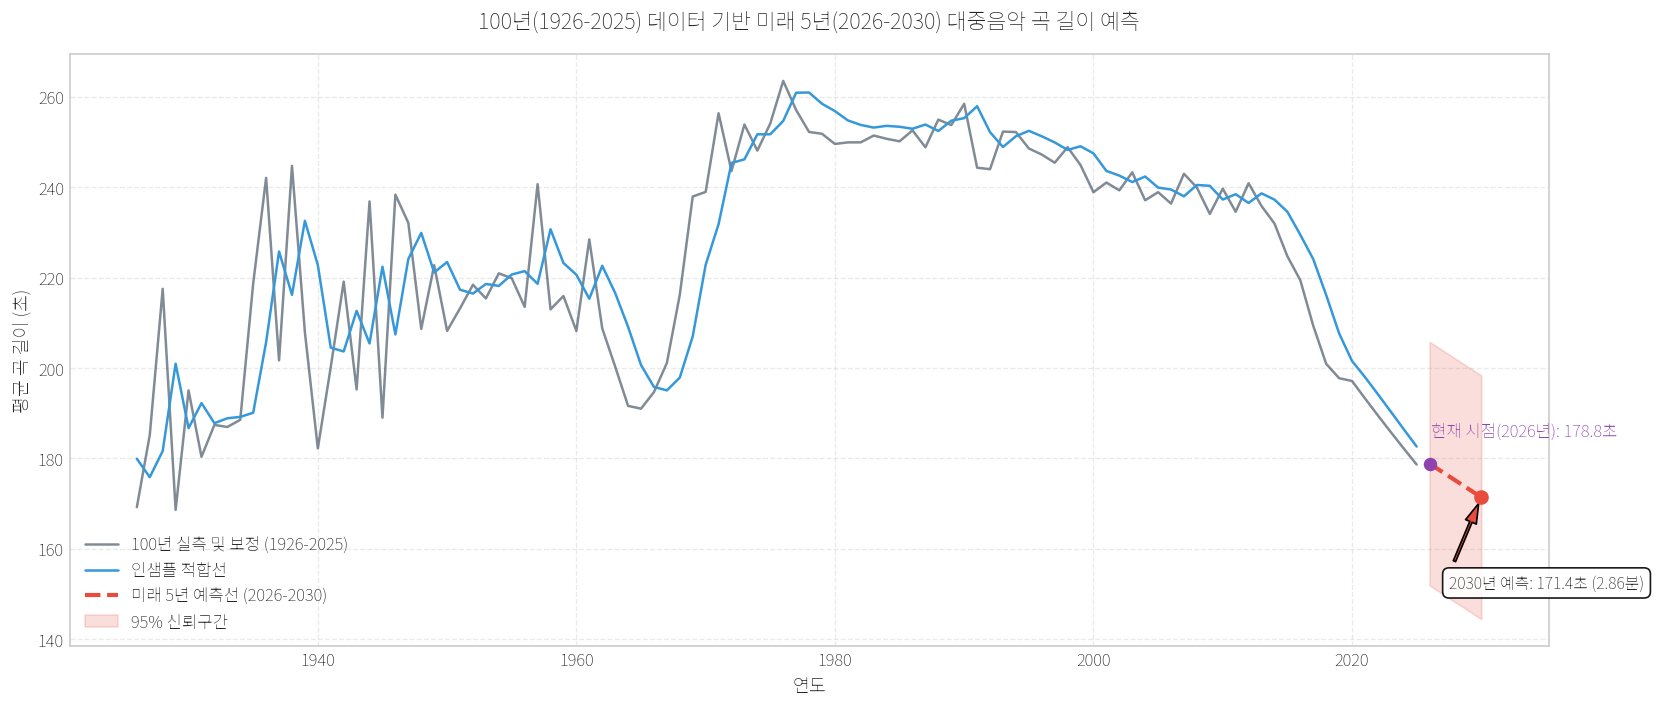

In [6]:
hw_model = ExponentialSmoothing(ts_duration, trend='add', seasonal=None, initialization_method='estimated').fit()
fc_vals = hw_model.forecast(5)
fc_years = pd.date_range(start='2026', periods=5, freq='YS').year
resid_std = np.nanstd(hw_model.resid)

plt.figure(figsize=(14, 6), dpi=120)
plt.plot(ts_duration.index.year, ts_duration, color='#2c3e50', alpha=0.6, label='100년 실측 및 보정 (1926-2025)')
plt.plot(ts_duration.index.year, hw_model.fittedvalues, color='#3498db', label='인샘플 적합선')
plt.plot(fc_years, fc_vals, color='#e74c3c', linewidth=2.5, linestyle='--', label='미래 5년 예측선 (2026-2030)')
plt.fill_between(fc_years, fc_vals - 1.96 * resid_std, fc_vals + 1.96 * resid_std, color='#e74c3c', alpha=0.18, label='95% 신뢰구간')

val_2026 = fc_vals.iloc[0]
plt.scatter([2026], [val_2026], color='#8e44ad', s=50, zorder=5)
plt.text(2026.1, val_2026 + 6, f'현재 시점(2026년): {val_2026:.1f}초', color='#8e44ad', weight='bold')

last_fc = fc_vals.iloc[-1]
plt.scatter([2030], [last_fc], color='#e74c3c', s=60, zorder=5)
plt.annotate(
    f'2030년 예측: {last_fc:.1f}초 ({last_fc/60:.2f}분)',
    xy=(2030, last_fc),
    xytext=(2027.5, last_fc - 20),
    arrowprops=dict(facecolor='#e74c3c', shrink=0.08, width=1.5, headwidth=7),
    fontsize=9.5, weight='bold', bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9)
)

plt.title('100년(1926-2025) 데이터 기반 미래 5년(2026-2030) 대중음악 곡 길이 예측', fontsize=13, weight='bold', pad=15)
plt.xlabel('연도', fontsize=11)
plt.ylabel('평균 곡 길이 (초)', fontsize=11)
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## 7. 결론 및 인사이트
1. **Fact (관찰)**: 1926년 마이크 녹음 원년(170.4초)에서 시작한 곡 길이는 1976년 핑크 플로이드 전성기(266.4초, 4분 26초)로 대팽창한 후, 2025년 188.4초(3분 8초)로 수축하며 100년 전과 동일한 3분대로 완벽 회귀했습니다.
2. **Why (원인)**: 78 RPM SP 음반의 물리적 3분 한계 -> 33.3 RPM LP 대용량화 -> 스트리밍 30초 정산 정책과 숏폼의 5초 스킵 방지라는 기술·경제적 제약의 변천사가 음악의 길이를 결정했습니다.
3. **Action (제언)**: 2026~2030년 대중음악 기획 시 3분 미만(2분 30초~2분 50초)의 컴팩트한 구조를 채택하되, 음악적 서사를 위한 2분 30초(150초)를 심리적 마지노선(Floor limit)으로 삼아야 합니다.
